Actual Values: [0 1 1 0 1]
Predicted Values: [0 1 1 0 0]
Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5

Prediction: Purchased


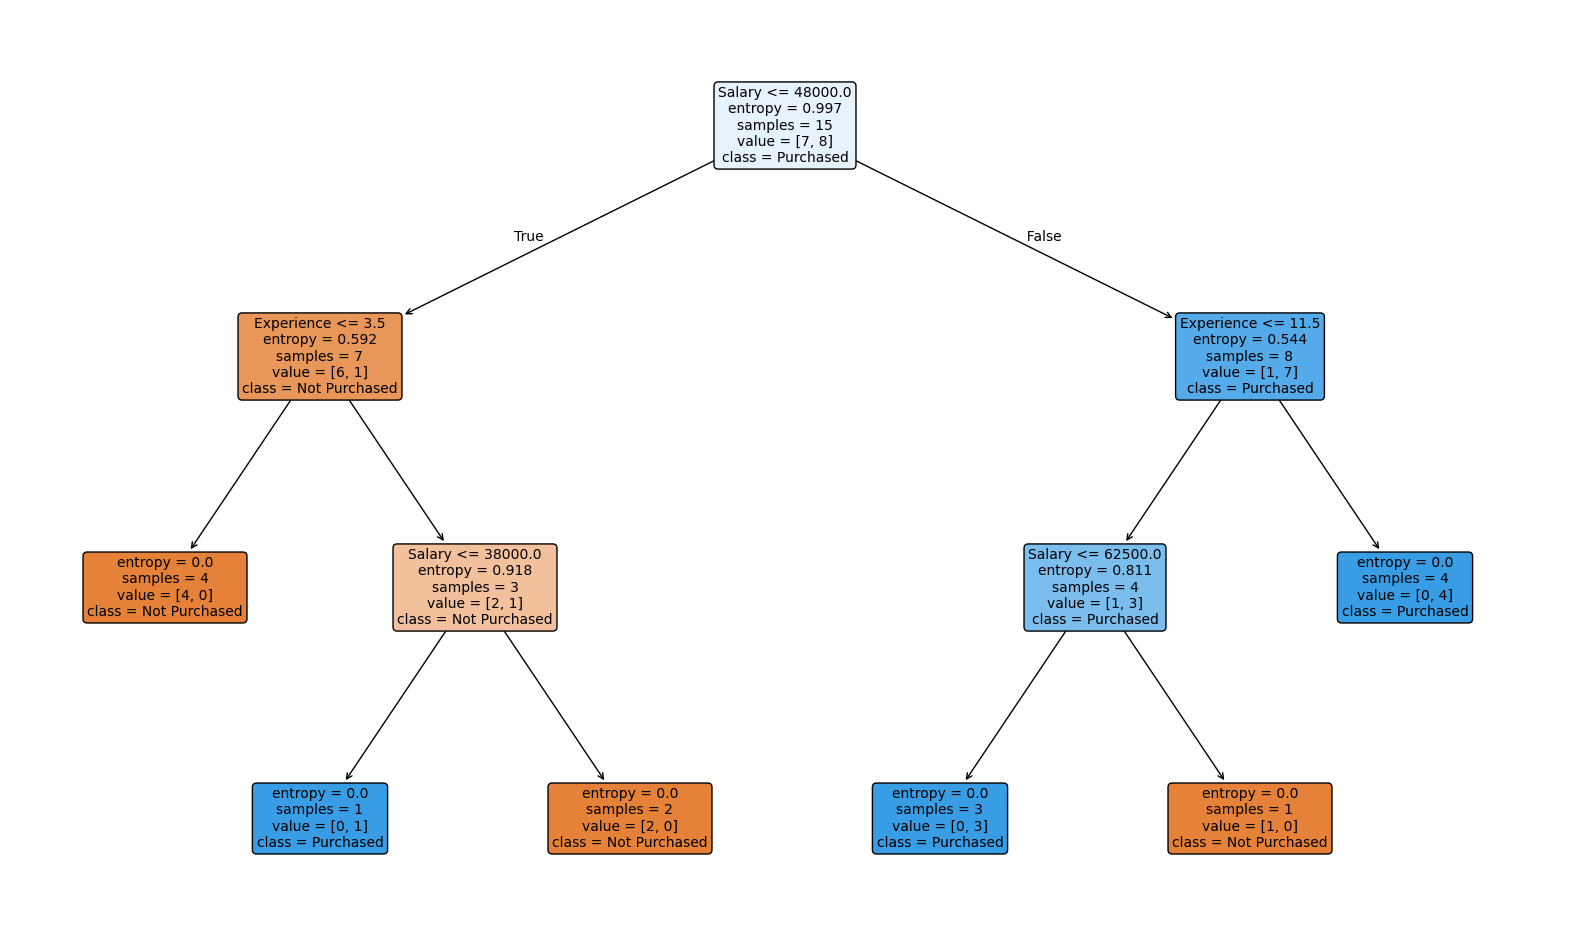

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

data = {
    "Age": [18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56],
    "Salary": [20000, 22000, 25000, 28000, 30000, 33000, 36000, 40000, 43000, 46000, 50000, 55000, 60000, 65000, 70000, 75000, 80000, 85000, 90000, 100000],
    "Experience": [0, 1, 1, 2, 3, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 20],
    "Purchased": [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

X = df[["Age", "Salary", "Experience"]]
y = df["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    min_samples_split=2,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Actual Values:", y_test.values)
print("Predicted Values:", y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

new_person = pd.DataFrame(
    [[35, 50000, 8]],
    columns=["Age", "Salary", "Experience"]
)

prediction = model.predict(new_person)

if prediction[0] == 1:
    print("Prediction: Purchased")
else:
    print("Prediction: Not Purchased")

plt.figure(figsize=(20, 12))

plot_tree(
    model,
    feature_names=["Age", "Salary", "Experience"],
    class_names=["Not Purchased", "Purchased"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()